In [18]:
# Block 1: Imports and Setup
import os
import cv2
import numpy as np
import mediapipe as mp
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model

In [2]:
# Block 2: Configuration and Folder Structure
actions = ["hello", "thankyou", "I love you", "yes", "no"]
DATASET_DIR   = "webcam"
KEYPOINTS_DIR = "data_keypoints"
SEQUENCE_LEN  = 30
VIDEOS_PER_ACTION = 40

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(KEYPOINTS_DIR, exist_ok=True)
for a in actions:
    os.makedirs(os.path.join(DATASET_DIR, a),   exist_ok=True)
    os.makedirs(os.path.join(KEYPOINTS_DIR, a), exist_ok=True)

In [3]:
# Block 3: Mediapipe Helpers
mp_holistic = mp.solutions.holistic
mp_draw     = mp.solutions.drawing_utils

def mediapipe_detection(img, model):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb.flags.writeable = False
    res = model.process(img_rgb)
    img_rgb.flags.writeable = True
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR), res

def draw_landmarks(img, res):
    # note: face connections removed because they are not useful
    mp_draw.draw_landmarks(img, res.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
    mp_draw.draw_landmarks(img, res.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
    mp_draw.draw_landmarks(img, res.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

def extract_keypoints(res):
    # pose: 33 landmarks × (x,y,z,visibility)
    pose = np.array([[l.x, l.y, l.z, l.visibility] for l in res.pose_landmarks.landmark]).flatten() \
           if res.pose_landmarks else np.zeros(33*4)
    # left hand: 21 landmarks × (x,y,z)
    lh   = np.array([[l.x, l.y, l.z] for l in res.left_hand_landmarks.landmark]).flatten() \
           if res.left_hand_landmarks else np.zeros(21*3)
    # right hand: 21 landmarks × (x,y,z)
    rh   = np.array([[l.x, l.y, l.z] for l in res.right_hand_landmarks.landmark]).flatten() \
           if res.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, lh, rh])


In [4]:
# Block 4: User Interaction for Data Collection
print("Available Actions:", actions)
use_existing = input("Use existing videos? (y/n): ").strip().lower().startswith('y')
to_record = []

if not use_existing:
    print("\nChoose recording mode:")
    print("1 - Record a single action")
    print("2 - Record multiple actions (comma-separated)")
    print("3 - Record all actions")
    mode = input("Select option [1/2/3]: ").strip()

    if mode == '1':
        act = input("Enter action: ").strip()
        if act in actions:
            to_record = [act]
        else:
            print(f"'{act}' is not a valid action.")
    elif mode == '2':
        picked = input("Enter comma-separated actions: ").split(',')
        to_record = [a.strip() for a in picked if a.strip() in actions]
        invalid = [a.strip() for a in picked if a.strip() not in actions]
        if invalid:
            print("Invalid actions ignored:", invalid)
    elif mode == '3':
        to_record = actions
    else:
        print("Invalid selection.")
    
    if not to_record:
        print("No valid actions selected. Exiting.")
        exit()

Available Actions: ['hello', 'thankyou', 'I love you', 'yes', 'no']

Choose recording mode:
1 - Record a single action
2 - Record multiple actions (comma-separated)
3 - Record all actions


In [5]:
# Block 5: Video Recording Function
import time  
def record_videos(actions_list):
    cap = cv2.VideoCapture(0)
    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as hol:
        for action in actions_list:
            for vid_num in range(VIDEOS_PER_ACTION):
                
                # Show preparation text
                start_time = time.time()
                while time.time() - start_time < 2:
                    ret, frame = cap.read()
                    if not ret:
                        continue
                    cv2.putText(frame, f"Get ready: {action} {vid_num+1}/{VIDEOS_PER_ACTION}", 
                                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
                    cv2.imshow("Recording", frame)
                    if cv2.waitKey(10) & 0xFF == ord('q'):
                        cap.release()
                        cv2.destroyAllWindows()
                        return
                
                # Start recording
                frames = []
                for f in range(SEQUENCE_LEN):
                    ret, frame = cap.read()
                    if not ret:
                        continue
                    cv2.putText(frame, f"{action} {vid_num+1}/{VIDEOS_PER_ACTION}", (10, 30),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                    cv2.imshow("Recording", frame)
                    frames.append(frame)
                    if cv2.waitKey(10) & 0xFF == ord('q'):
                        break

                # Save raw video frames
                vid_path = os.path.join(DATASET_DIR, action, str(vid_num))
                os.makedirs(vid_path, exist_ok=True)
                for idx, frm in enumerate(frames):
                    cv2.imwrite(os.path.join(vid_path, f"{idx}.jpg"), frm)
                    
    cap.release()
    cv2.destroyAllWindows()

if not use_existing:
    record_videos(to_record)


In [6]:
# Block 6: Keypoint Extraction
actions_to_process = to_record if not use_existing else actions
def extract_all_keypoints(actions_to_process):
    for action in actions_to_process:
        action_path = os.path.join(DATASET_DIR, action)
        if not os.path.exists(action_path): continue

        for vid in os.listdir(action_path):
            vid_path = os.path.join(action_path, vid)
            kp_path  = os.path.join(KEYPOINTS_DIR, action, vid)
            os.makedirs(kp_path, exist_ok=True)

            with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as hol:
                for f in sorted(os.listdir(vid_path), key=lambda x: int(x.split('.')[0])):
                    img = cv2.imread(os.path.join(vid_path, f))
                    if img is None: continue
                    img, res = mediapipe_detection(img, hol)
                    kp = extract_keypoints(res)
                    np.save(os.path.join(kp_path, f.split('.')[0]), kp)

# Call appropriately based on whether user recorded new videos
if use_existing:
    extract_all_keypoints(actions)
else:
    extract_all_keypoints(to_record)


In [7]:
# Block 7: Prepare Data for Training
label_map = {a:i for i,a in enumerate(actions)}
sequences, labels = [], []
for action in actions:
    for seq in sorted(os.listdir(os.path.join(KEYPOINTS_DIR, action)), key=int):
        window = [np.load(os.path.join(KEYPOINTS_DIR, action, seq, f"{i}.npy")) 
                  for i in range(SEQUENCE_LEN)]
        sequences.append(window)
        labels.append(label_map[action])

X = np.array(sequences)
y = to_categorical(labels).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [19]:
# Block 8: Model Loading or Creation
FEATURE_DIM = 33*4 + 21*3 + 21*3  # = 132 + 63 + 63 = 258

model_path = "action.h5"
if os.path.exists(model_path):
    model = load_model(model_path)
    print("Loaded existing model.")
else:
    model = Sequential([
        LSTM(64,  return_sequences=True,  activation='relu', input_shape=(SEQUENCE_LEN, FEATURE_DIM)),
        LSTM(128, return_sequences=True,  activation='relu'),
        LSTM(128, return_sequences=True,  activation='relu'), # added extra LSTM layer 
        LSTM(64,  return_sequences=False, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(len(actions), activation='softmax')
    ])
    model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
    print("Created new model")

model.summary()

Loaded existing model.
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 30, 64)            82688     
                                                                 
 lstm_5 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_6 (LSTM)               (None, 30, 128)           131584    
                                                                 
 lstm_7 (LSTM)               (None, 64)                49408     
                                                                 
 dense_3 (Dense)             (None, 64)                4160      
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (N

In [23]:
# Block 9: Training
tb_cb = TensorBoard(log_dir="Logs")
model.fit(X_train, y_train, epochs=20, callbacks=[tb_cb])
model.save(model_path)

Epoch 1/20
6/6 [==============================] - 0s 43ms/step - loss: 0.6374 - categorical_accuracy: 0.7278
Epoch 2/20
6/6 [==============================] - 0s 47ms/step - loss: 0.5697 - categorical_accuracy: 0.7722
Epoch 3/20
6/6 [==============================] - 0s 55ms/step - loss: 0.5715 - categorical_accuracy: 0.7556
Epoch 4/20
6/6 [==============================] - 0s 56ms/step - loss: 0.5395 - categorical_accuracy: 0.7500
Epoch 5/20
6/6 [==============================] - 0s 55ms/step - loss: 0.5014 - categorical_accuracy: 0.7833
Epoch 6/20
6/6 [==============================] - 0s 53ms/step - loss: 0.4516 - categorical_accuracy: 0.8056
Epoch 7/20
6/6 [==============================] - 0s 52ms/step - loss: 0.4404 - categorical_accuracy: 0.8000
Epoch 8/20
6/6 [==============================] - 0s 51ms/step - loss: 0.4320 - categorical_accuracy: 0.7944
Epoch 9/20
6/6 [==============================] - 0s 55ms/step - loss: 0.3911 - categorical_accuracy: 0.8389
Epoch 10/20
6/6 [==

1/1 [==============================] - 0s 34ms/step
Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

       hello       0.89      1.00      0.94         8
    thankyou       1.00      1.00      1.00         4
  I love you       1.00      0.33      0.50         3
         yes       0.33      0.33      0.33         3
          no       0.33      0.50      0.40         2

    accuracy                           0.75        20
   macro avg       0.71      0.63      0.63        20
weighted avg       0.79      0.75      0.74        20



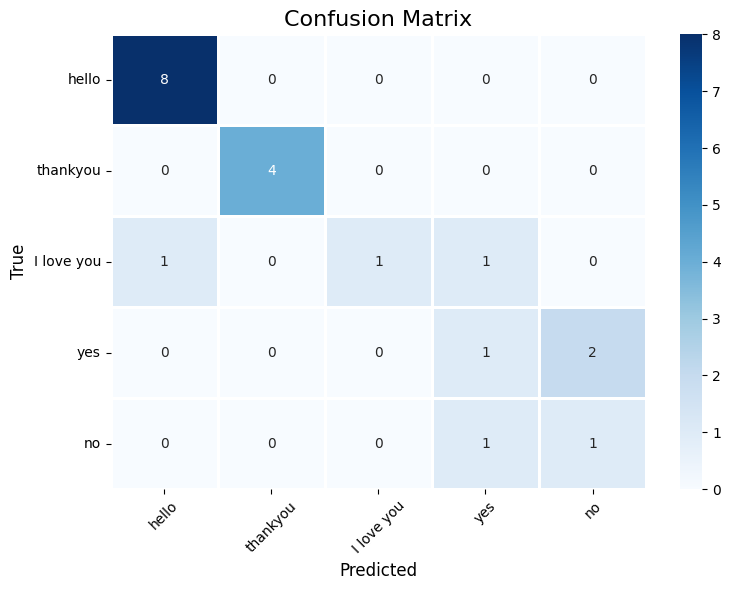

In [24]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set
yhat = np.argmax(model.predict(X_test), axis=1)
ytrue = np.argmax(y_test, axis=1)

# Print overall accuracy
print("Accuracy:", accuracy_score(ytrue, yhat))

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(ytrue, yhat, target_names=actions))

# Generate confusion matrix
cm = confusion_matrix(ytrue, yhat)

# Plot confusion matrix using white-blue colormap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=actions, yticklabels=actions,
            cbar=True, linecolor='white', linewidths=1)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [21]:
# Block 11: Real‑Time Detection
def prob_viz(res, actions, frame):
    overlay = frame.copy()
    for i, prob in enumerate(res):
        cv2.rectangle(overlay, (0, 60 + i*40), (int(prob*100), 90 + i*40), (0,255,0), -1)
        cv2.putText(overlay, f"{actions[i]} {prob:.2f}", (5, 85 + i*40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
    return overlay

cap = cv2.VideoCapture(0)
seq, sen, preds = [], [], []
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as hol:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        img, res = mediapipe_detection(frame, hol)
        draw_landmarks(img, res)
        kp = extract_keypoints(res)
        seq.append(kp); seq = seq[-SEQUENCE_LEN:]

        if len(seq) == SEQUENCE_LEN:
            p = model.predict(np.expand_dims(seq, axis=0))[0]
            if p.max() > 0.7:
                action = actions[np.argmax(p)]
                if not sen or action != sen[-1]:
                    sen.append(action)
            img = prob_viz(p, actions, img)
        else:
            # Default visualization when not enough sequence
            img = prob_viz([0]*len(actions), actions, img)

        cv2.putText(img, ' '.join(sen[-5:]), (10, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        cv2.imshow("Sign Detection", img)
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


1/1 [==============================] - 0s 22ms/step


In [14]:
import tensorflow as tf

model = tf.keras.models.load_model("action.h5")   # still succeeds here
model.save("action.keras", save_format="keras")   # one‑liner conversion
print("Saved new model → action.keras")

OSError: No file or directory found at action.h5